# 行星轨道数值模拟

## 项目目的

本项目旨在通过数值求解牛顿万有引力定律下的二体问题，模拟行星绕太阳的运动轨迹。具体目标包括：

1. 建立太阳-行星系统的微分方程模型
2. 使用 Python 的 `scipy.integrate.solve_ivp` 进行高精度数值积分
3. 绘制行星轨道，直观验证开普勒第一定律（椭圆轨道）
4. 通过改变初速度，观察圆形、椭圆、抛物线、双曲线轨道的形成条件

## 背景介绍

### 开普勒三定律

17世纪初，约翰内斯·开普勒通过分析第谷·布拉赫的天文观测数据，总结出行星运动的三大定律：

- **第一定律（轨道定律）**：行星绕太阳运动的轨道是椭圆，太阳位于椭圆的一个焦点上
- **第二定律（面积定律）**：行星与太阳的连线在相等时间内扫过相等面积
- **第三定律（周期定律）**：行星公转周期的平方与轨道半长轴的立方成正比

### 牛顿万有引力定律

1687年，牛顿在《自然哲学的数学原理》中提出万有引力定律，从理论上导出了开普勒定律：

$$ \vec{F} = -\frac{GMm}{r^2} \hat{r} $$

其中 $G$ 为万有引力常数，$M$ 为太阳质量，$m$ 为行星质量，$r$ 为两天体间距离，$\hat{r}$ 为单位方向向量。

## 物理模型与公式推导

### 基本假设

为简化问题，采用以下假设：

1. **太阳固定不动**：$M_\odot \gg m_\text{planet}$，太阳可视为固定在原点
2. **只考虑引力**：忽略其他天体的摄动、相对论效应等
3. **二维平面运动**：行星轨道位于一个平面内

### 运动方程推导

根据牛顿第二定律 $ \vec{F} = m\vec{a} $ 和万有引力定律：

$$ m\frac{d^2\vec{r}}{dt^2} = -\frac{GM_\odot m}{r^2}\hat{r} $$

消去行星质量 $m$：

$$ \frac{d^2\vec{r}}{dt^2} = -\frac{GM_\odot}{r^3}\vec{r} $$

### 一阶微分方程组

将二阶微分方程化为一阶方程组。定义状态向量 $ \vec{y} = (x, y, v_x, v_y)^T $：

$$ \begin{cases}
\dfrac{dx}{dt} = v_x \\[10pt]
\dfrac{dy}{dt} = v_y \\[10pt]
\dfrac{dv_x}{dt} = -\dfrac{GM_\odot}{r^3} x \\[10pt]
\dfrac{dv_y}{dt} = -\dfrac{GM_\odot}{r^3} y
\end{cases} $$

其中 $ r = \sqrt{x^2 + y^2} $。

### 无量纲化（天文单位制）

为了数值计算的稳定性，采用天文单位制：

| 物理量 | 单位 | 数值 |
|--------|------|------|
| 长度 | AU（天文单位） | 1 AU = $1.496 \times 10^{11}$ m |
| 时间 | 年（yr） | 1 yr = $3.156 \times 10^7$ s |
| 质量 | $M_\odot$（太阳质量） | 1 $M_\odot = 1.989 \times 10^{30}$ kg |

在此单位制下，地球轨道半径 $r = 1$ AU，周期 $T = 1$ yr。

由开普勒第三定律 $T^2 = \frac{4\pi^2}{GM_\odot} a^3$，代入 $T=1, a=1$，得到：

$$ GM_\odot = 4\pi^2 \approx 39.478 $$

这使得数值计算无需处理天文数字。

✅ 使用系统字体: Microsoft YaHei


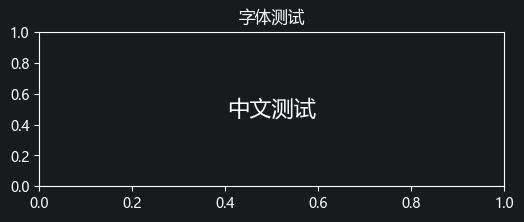

In [9]:
# ============================================
# 零. 字体导入
# ============================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 方案：直接使用 Windows 自带的微软雅黑或宋体
# 按优先级尝试多个常见中文字体
font_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'FangSong']

# 获取系统所有可用字体
available_fonts = [f.name for f in fm.fontManager.ttflist]

# 找到第一个可用的中文字体
selected_font = None
for font_name in font_candidates:
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    print(f'✅ 使用系统字体: {selected_font}')
    plt.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']
else:
    print('⚠️ 未找到中文字体，将使用英文显示')
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['axes.unicode_minus'] = False

# 快速测试
plt.figure(figsize=(6, 2))
plt.text(0.5, 0.5, '中文测试', ha='center', va='center', fontsize=16)
plt.title('字体测试')
plt.show()

In [10]:
# 一.导入必要的科学计算和可视化库
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# ★★★ 在这里指定你想保存图片的文件夹路径 ★★★
# ============================================================
# 写法1：绝对路径（推荐，最保险）
IMAGES_DIR = r"C:\Users\30866\PycharmProjects\PythonProject\planet-orbit-simulation\images"
# ============================================================
# 创建文件夹（如果不存在）
# ============================================================
os.makedirs(IMAGES_DIR, exist_ok=True)
print(f"✅ 图片将保存到: {os.path.abspath(IMAGES_DIR)}")

✅ 图片将保存到: C:\Users\30866\PycharmProjects\PythonProject\planet-orbit-simulation\images


In [11]:
# 二.定义微分方程
def gravity(t, state):
    """
    行星在太阳引力作用下的运动方程

    参数:
        t: 时间（天文单位制下以年为单位）
        state: 状态向量 [x, y, vx, vy]
            x, y  : 行星位置 (AU)
            vx, vy: 行星速度 (AU/yr)

    返回:
        dstate: 状态向量的导数 [dx/dt, dy/dt, dvx/dt, dvy/dt]
    """
    # 解包状态向量
    x, y, vx, vy = state

    # 计算行星到太阳的距离
    r = np.sqrt(x**2 + y**2)
    r3 = r**3  # 距离的立方，避免重复计算

    # 天文单位制下的引力常数 GM = 4π²
    GM = 4 * np.pi**2

    # 计算加速度分量
    ax = -GM * x / r3  # x方向加速度
    ay = -GM * y / r3  # y方向加速度

    # 返回导数
    return [vx, vy, ax, ay]

In [12]:
# ============================================
# 三.初始条件设置
# ============================================

# 方案一：地球参数 —— 近似圆形轨道
# 日地平均距离 1 AU，轨道速度约 2π AU/yr
x0 = 1.0           # 初始 x 位置 (AU)
y0 = 0.0           # 初始 y 位置 (AU)
vx0 = 0.0          # 初始 x 方向速度 (AU/yr)
vy0 = 2 * np.pi    # 初始 y 方向速度 (AU/yr)，约 6.283

# ============================================
# 时间范围设置
# ============================================
t_start = 0.0      # 起始时间 (yr)
t_end = 2.0        # 结束时间 (yr)，模拟2年
n_points = 1000    # 输出数据点数

# 初始状态向量
initial_state = [x0, y0, vx0, vy0]

# 时间跨度
t_span = (t_start, t_end)

# 均匀的时间点（用于输出结果）
t_eval = np.linspace(t_start, t_end, n_points)

# 打印初始条件供检查
print("=" * 50)
print("初始条件")
print("=" * 50)
print(f"位置: ({x0}, {y0}) AU")
print(f"速度: ({vx0:.4f}, {vy0:.4f}) AU/yr")
print(f"初始速率: {np.sqrt(vx0**2 + vy0**2):.4f} AU/yr")
print(f"模拟时间: {t_start} ~ {t_end} 年")
print(f"数据点数: {n_points}")
print("=" * 50)

初始条件
位置: (1.0, 0.0) AU
速度: (0.0000, 6.2832) AU/yr
初始速率: 6.2832 AU/yr
模拟时间: 0.0 ~ 2.0 年
数据点数: 1000


In [13]:
# ============================================
# 四.使用 solve_ivp 进行数值积分
# ============================================

# solve_ivp 使用自适应步长的 Runge-Kutta 方法
solution = solve_ivp(
    gravity,           # 微分方程函数
    t_span,            # 时间范围 (t_start, t_end)
    initial_state,     # 初始状态
    t_eval=t_eval,     # 在指定的时间点输出结果
    rtol=1e-9,         # 相对误差容限（越小越精确）
    atol=1e-12         # 绝对误差容限
)

# ============================================
# 提取结果
# ============================================
x = solution.y[0]    # x 坐标数组
y = solution.y[1]    # y 坐标数组
vx = solution.y[2]   # x 方向速度数组
vy = solution.y[3]   # y 方向速度数组
t = solution.t       # 时间数组

# 计算轨道统计量
r = np.sqrt(x**2 + y**2)          # 每个时刻的日地距离
speed = np.sqrt(vx**2 + vy**2)    # 每个时刻的速率

# ============================================
# 输出模拟结果统计
# ============================================
print("=" * 50)
print("模拟结果统计")
print("=" * 50)
print(f"求解状态: {'成功 ✅' if solution.success else '失败 ❌'}")
print(f"函数求值次数: {solution.nfev}")
print(f"数据点数: {len(t)}")
print(f"轨道平均距离: {np.mean(r):.6f} AU")
print(f"距离标准差: {np.std(r):.6f} AU（越小越接近正圆）")
print(f"平均速率: {np.mean(speed):.4f} AU/yr")
print("=" * 50)

模拟结果统计
求解状态: 成功 ✅
函数求值次数: 1532
数据点数: 1000
轨道平均距离: 1.000000 AU
距离标准差: 0.000000 AU（越小越接近正圆）
平均速率: 6.2832 AU/yr


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


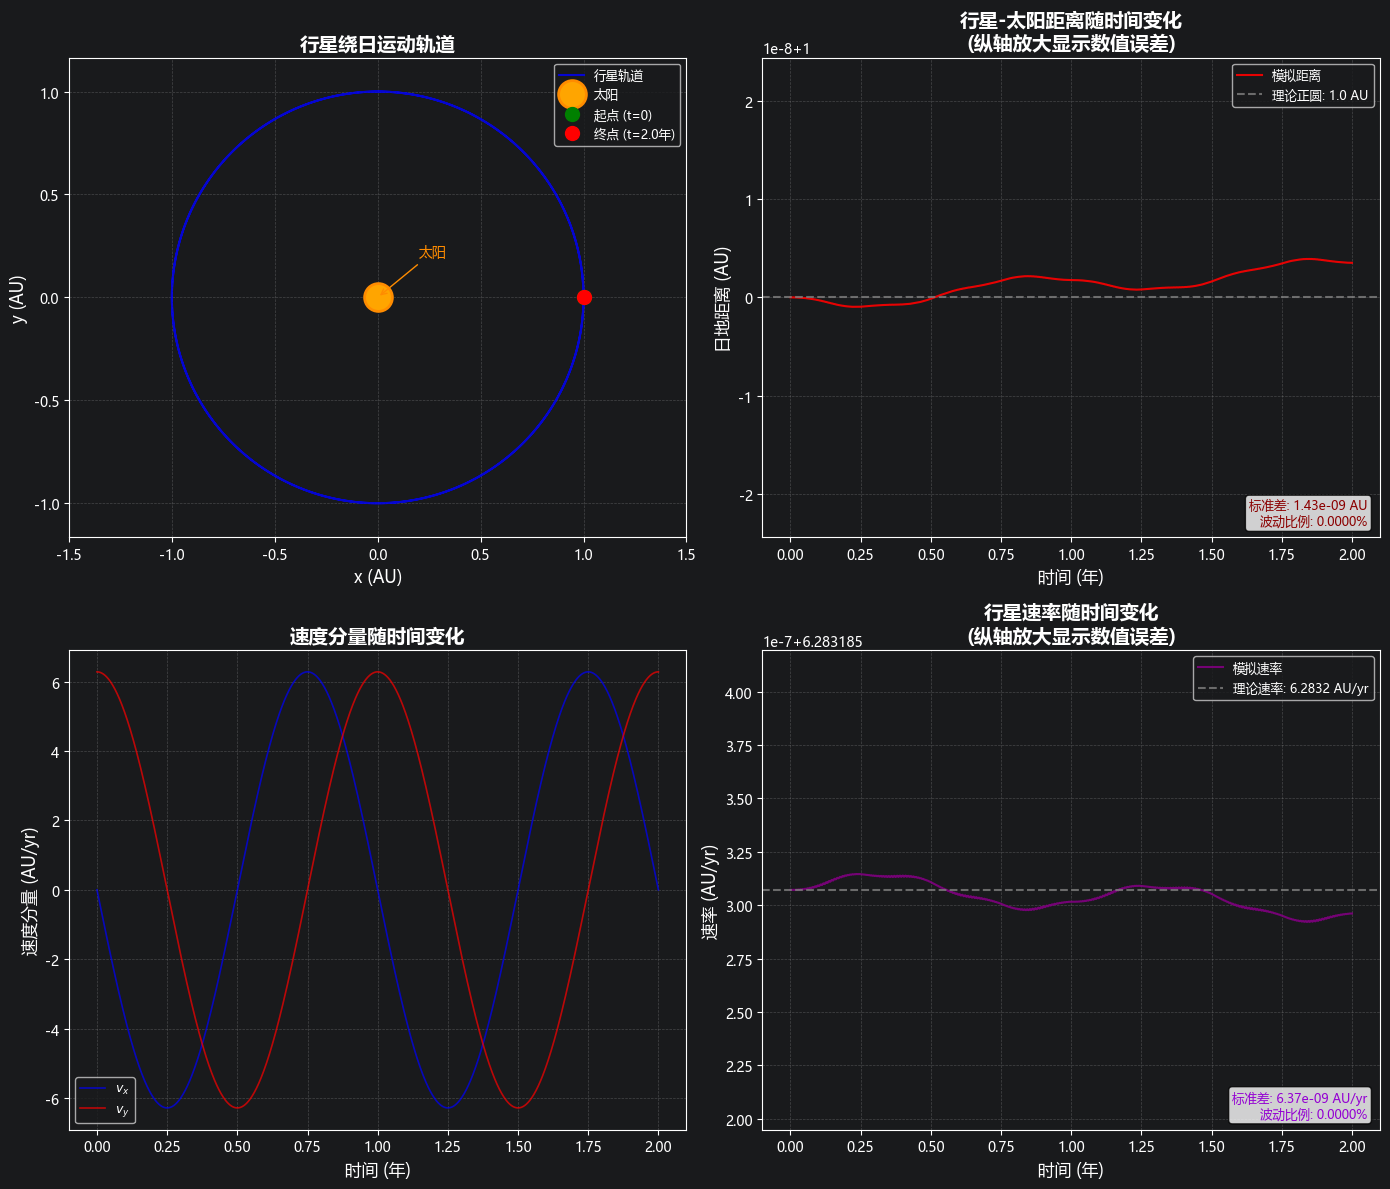

✅ 修正版图表已生成并保存为 'images/planet_orbit_results.png'


In [14]:
# ============================================
# 五. 行星轨道可视化（修正版）
# ============================================

# 创建画布：2行2列共4个子图
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ------ 子图1：轨道图 ------
ax1 = axes[0, 0]
ax1.plot(x, y, 'b-', linewidth=1.5, alpha=0.8, label='行星轨道')
ax1.plot(0, 0, 'o', color='orange', markersize=20, label='太阳',
         markeredgecolor='darkorange', markeredgewidth=2)
ax1.plot(x[0], y[0], 'go', markersize=10, label='起点 (t=0)')
ax1.plot(x[-1], y[-1], 'ro', markersize=10, label=f'终点 (t={t_end}年)')
ax1.set_xlabel('x (AU)', fontsize=12)
ax1.set_ylabel('y (AU)', fontsize=12)
ax1.set_title('行星绕日运动轨道', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axis('equal')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)

# 在太阳位置添加文字标注
ax1.annotate('太阳', xy=(0, 0), xytext=(0.2, 0.2),
            fontsize=10, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'))

# ------ 子图2：距离随时间变化（修正版）------
ax2 = axes[0, 1]

# 计算理论正圆半径（初始距离）
r_circular = np.sqrt(x0**2 + y0**2)  # 1.0 AU

# 绘制实际距离曲线（显示微小波动）
ax2.plot(t, r, 'r-', linewidth=1.5, alpha=0.9, label='模拟距离')
# 绘制理论正圆参考线
ax2.axhline(y=r_circular, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'理论正圆: {r_circular} AU')

# 自动调整纵轴范围，以同时展示波动和参考线
r_min = np.min(r)
r_max = np.max(r)
# 计算波动幅度，并给纵轴留出适当余量
r_range = max(r_max - r_min, 1e-10)  # 防止零范围
margin = r_range * 5  # 上下各留5倍波动范围的余量
ax2.set_ylim(r_circular - margin, r_circular + margin)

ax2.set_xlabel('时间 (年)', fontsize=12)
ax2.set_ylabel('日地距离 (AU)', fontsize=12)
ax2.set_title('行星-太阳距离随时间变化\n(纵轴放大显示数值误差)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# 在图上标注波动量级
r_std = np.std(r)
ax2.text(0.98, 0.02, f'标准差: {r_std:.2e} AU\n波动比例: {r_std/r_circular*100:.4f}%',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=9, color='darkred',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------ 子图3：速度随时间变化 ------
ax3 = axes[1, 0]
ax3.plot(t, vx, 'b-', linewidth=1.2, alpha=0.7, label='$v_x$')
ax3.plot(t, vy, 'r-', linewidth=1.2, alpha=0.7, label='$v_y$')
ax3.set_xlabel('时间 (年)', fontsize=12)
ax3.set_ylabel('速度分量 (AU/yr)', fontsize=12)
ax3.set_title('速度分量随时间变化', fontsize=14, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--')

# ------ 子图4：速率随时间变化（修正版）------
ax4 = axes[1, 1]

# 理论圆形轨道速率
v_circular = 2 * np.pi

# 绘制实际速率曲线
ax4.plot(t, speed, 'purple', linewidth=1.5, alpha=0.9, label='模拟速率')
# 绘制理论正圆参考线
ax4.axhline(y=v_circular, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'理论速率: {v_circular:.4f} AU/yr')

# 自动调整纵轴范围
speed_min = np.min(speed)
speed_max = np.max(speed)
speed_range = max(speed_max - speed_min, 1e-10)
margin_v = speed_range * 5
ax4.set_ylim(v_circular - margin_v, v_circular + margin_v)

ax4.set_xlabel('时间 (年)', fontsize=12)
ax4.set_ylabel('速率 (AU/yr)', fontsize=12)
ax4.set_title('行星速率随时间变化\n(纵轴放大显示数值误差)', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')

# 标注波动量级
speed_std = np.std(speed)
ax4.text(0.98, 0.02, f'标准差: {speed_std:.2e} AU/yr\n波动比例: {speed_std/v_circular*100:.4f}%',
         transform=ax4.transAxes, ha='right', va='bottom',
         fontsize=9, color='darkviolet',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'planet_orbit_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ 修正版图表已生成并保存为 'images/planet_orbit_results.png'")

## 结果分析与验证

### 圆形轨道验证

如果行星轨道的距离标准差很小（$\sigma_r \ll 1$ AU），说明轨道接近正圆。这是因为我们选择了初始速度 $v_y = 2\pi$ AU/yr，恰好满足圆形轨道的条件：

$$ v_{\text{circular}} = \sqrt{\frac{GM}{r}} = \sqrt{\frac{4\pi^2}{1}} = 2\pi $$

### 能量守恒检查

系统的总机械能应保持不变：

$$ E = \frac{1}{2}mv^2 - \frac{GMm}{r} $$

（这里我们略去 $m$，检查比能量 $E/m$ 是否为常数）

总能量标准差应远小于能量本身，这是数值积分精度的重要指标。

守恒量检查
总能量均值: -19.7392087689 (AU/yr)²
总能量标准差: 2.01e-08 (AU/yr)²
总能量相对误差: 0.000000%
角动量均值: 6.2831853125 AU²/yr
角动量标准差: 3.20e-09 AU²/yr
角动量相对误差: 0.000000%


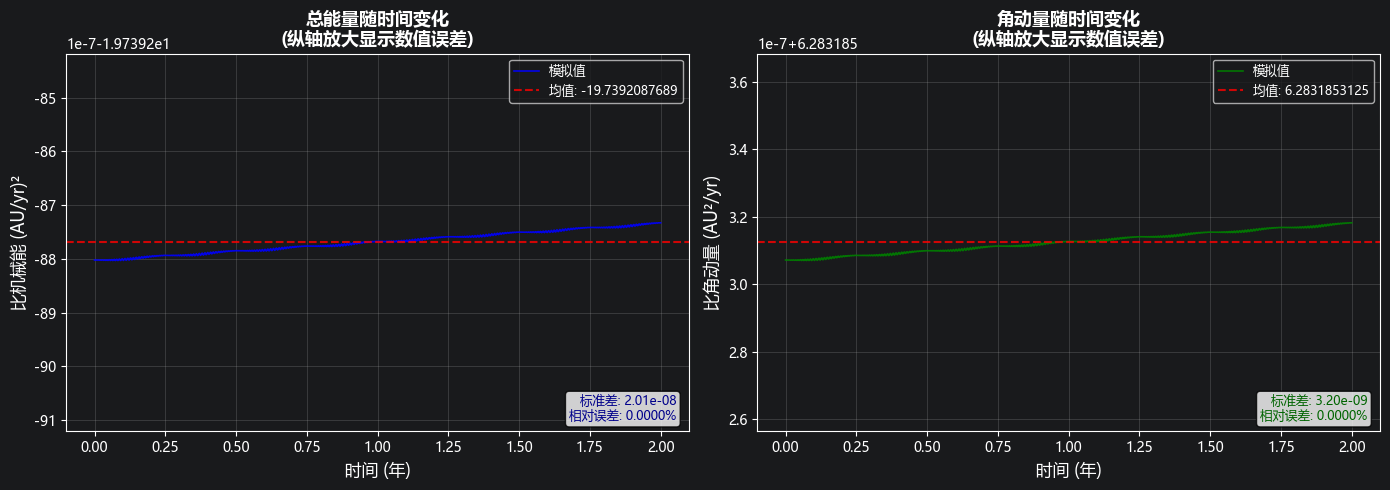

✅ 修正版守恒量图表已保存为 'images/conservation_check.png'


In [15]:
# ============================================
# 能量守恒验证
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# 1. 重新运行求解（确保数据一致）
# ============================================
def gravity(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)
    r3 = r**3
    GM = 4 * np.pi**2
    ax = -GM * x / r3
    ay = -GM * y / r3
    return [vx, vy, ax, ay]

x0, y0 = 1.0, 0.0
vx0, vy0 = 0.0, 2 * np.pi
t_start, t_end = 0.0, 2.0
n_points = 1000

initial_state = [x0, y0, vx0, vy0]
t_span = (t_start, t_end)
t_eval = np.linspace(t_start, t_end, n_points)

solution = solve_ivp(
    gravity,
    t_span,
    initial_state,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-12
)

x = solution.y[0]
y = solution.y[1]
vx = solution.y[2]
vy = solution.y[3]
t = solution.t
r = np.sqrt(x**2 + y**2)
speed = np.sqrt(vx**2 + vy**2)

# ============================================
# 2. 计算守恒量
# ============================================
GM = 4 * np.pi**2

kinetic_energy = 0.5 * speed**2
potential_energy = -GM / r
total_energy = kinetic_energy + potential_energy

angular_momentum = x * vy - y * vx

# ============================================
# 3. 统计量
# ============================================
E_mean = np.mean(total_energy)
E_std = np.std(total_energy)
E_rel_err = np.abs(E_std / E_mean) * 100

L_mean = np.mean(angular_momentum)
L_std = np.std(angular_momentum)
L_rel_err = np.abs(L_std / L_mean) * 100

print("=" * 50)
print("守恒量检查")
print("=" * 50)
print(f"总能量均值: {E_mean:.10f} (AU/yr)²")
print(f"总能量标准差: {E_std:.2e} (AU/yr)²")
print(f"总能量相对误差: {E_rel_err:.6f}%")
print(f"角动量均值: {L_mean:.10f} AU²/yr")
print(f"角动量标准差: {L_std:.2e} AU²/yr")
print(f"角动量相对误差: {L_rel_err:.6f}%")
print("=" * 50)

# ============================================
# 4. 守恒量可视化
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ------ 左图：总能量随时间变化 ------
ax1.plot(t, total_energy, 'b-', linewidth=1.2, alpha=0.9, label='模拟值')
ax1.axhline(y=E_mean, color='r', linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'均值: {E_mean:.10f}')

# 关键：纵轴自动聚焦到波动范围
E_min, E_max = np.min(total_energy), np.max(total_energy)
E_range = max(E_max - E_min, 1e-15)
margin_E = E_range * 5
ax1.set_ylim(E_mean - margin_E, E_mean + margin_E)

ax1.set_xlabel('时间 (年)', fontsize=12)
ax1.set_ylabel('比机械能 (AU/yr)²', fontsize=12)
ax1.set_title('总能量随时间变化\n(纵轴放大显示数值误差)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 标注误差量级
ax1.text(0.98, 0.02,
         f'标准差: {E_std:.2e}\n相对误差: {E_rel_err:.4f}%',
         transform=ax1.transAxes, ha='right', va='bottom',
         fontsize=9, color='darkblue',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ------ 右图：角动量随时间变化 ------
ax2.plot(t, angular_momentum, 'g-', linewidth=1.2, alpha=0.9, label='模拟值')
ax2.axhline(y=L_mean, color='r', linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'均值: {L_mean:.10f}')

# 关键：纵轴自动聚焦到波动范围
L_min, L_max = np.min(angular_momentum), np.max(angular_momentum)
L_range = max(L_max - L_min, 1e-15)
margin_L = L_range * 5
ax2.set_ylim(L_mean - margin_L, L_mean + margin_L)

ax2.set_xlabel('时间 (年)', fontsize=12)
ax2.set_ylabel('比角动量 (AU²/yr)', fontsize=12)
ax2.set_title('角动量随时间变化\n(纵轴放大显示数值误差)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 标注误差量级
ax2.text(0.98, 0.02,
         f'标准差: {L_std:.2e}\n相对误差: {L_rel_err:.4f}%',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=9, color='darkgreen',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'conservation_check.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ 修正版守恒量图表已保存为 'images/conservation_check.png'")

## 拓展探索：初速度对轨道形状的影响

改变初始速度，可以观察到不同类型的圆锥曲线轨道：

- $v < v_{\text{circular}}$：椭圆轨道（太阳在远焦点）
- $v = v_{\text{circular}} = 2\pi$：圆形轨道
- $v_{\text{circular}} < v < v_{\text{escape}}$：椭圆轨道（太阳在近焦点）
- $v = v_{\text{escape}} = \sqrt{2}\,v_{\text{circular}} \approx 8.886$：抛物线轨道
- $v > v_{\text{escape}}$：双曲线轨道（行星将逃逸！）

下面我们来验证这一点。

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


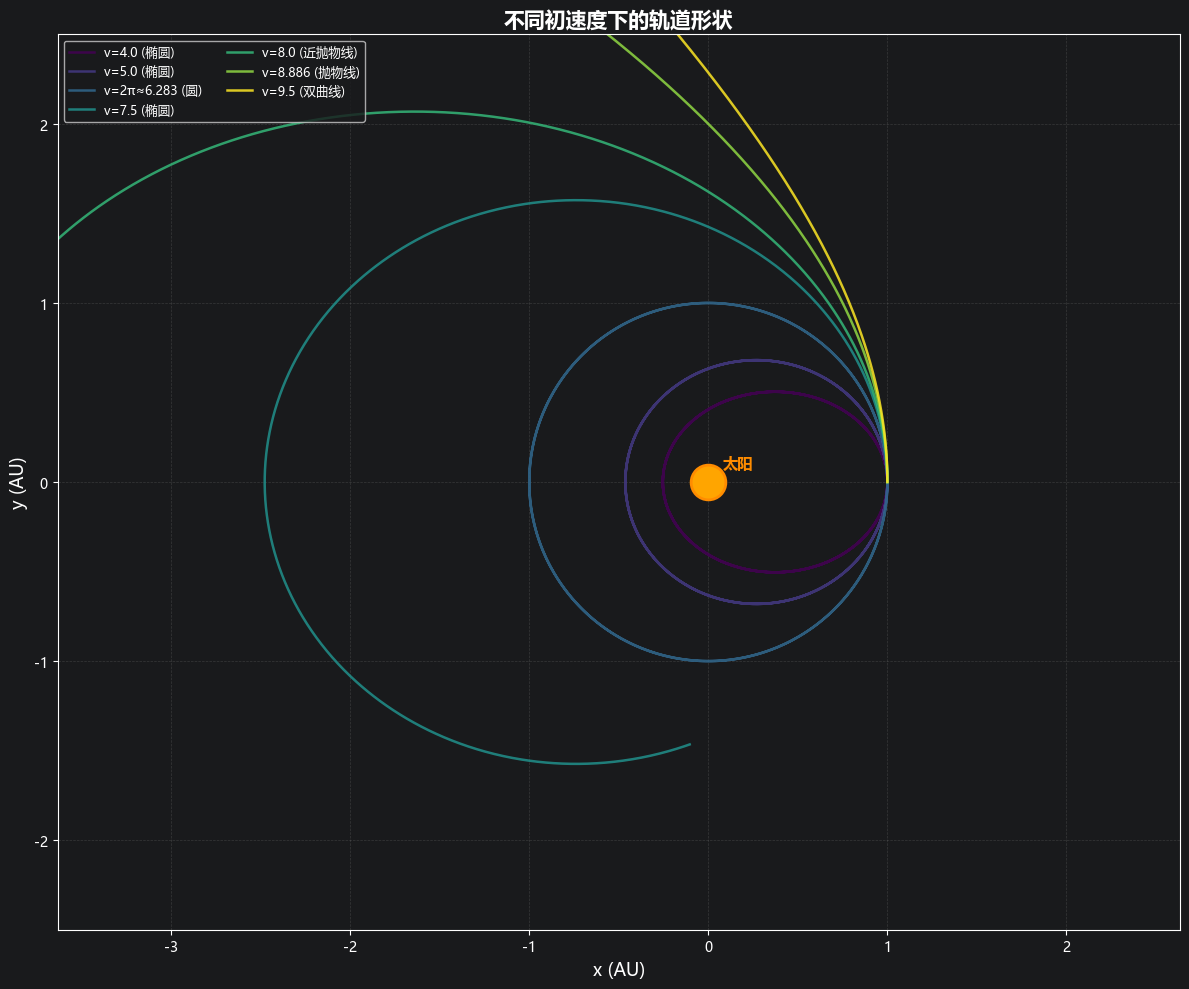

✅ 轨道对比图已保存为 'images/orbit_comparison.png'


In [16]:
# ============================================
# 比较不同初速度的轨道
# ============================================

# 定义多个初始vy值（在相同初始位置下）
vy_values = [4.0, 5.0, 2*np.pi, 7.5, 8.0, 8.886, 9.5]
vy_labels = [
    'v=4.0 (椭圆)',
    'v=5.0 (椭圆)',
    'v=2π≈6.283 (圆)',
    'v=7.5 (椭圆)',
    'v=8.0 (近抛物线)',
    'v=8.886 (抛物线)',
    'v=9.5 (双曲线)'
]
colors = plt.cm.viridis(np.linspace(0, 1, len(vy_values)))

fig, ax = plt.subplots(figsize=(12, 10))

for vy0, label, color in zip(vy_values, vy_labels, colors):
    # 设置初始条件：从 (1, 0) 出发，只有y方向速度不同
    init = [1.0, 0.0, 0.0, vy0]

    # 求解
    sol = solve_ivp(gravity, (0, 2), init, t_eval=t_eval, rtol=1e-9, atol=1e-12)
    x_sol, y_sol = sol.y[0], sol.y[1]

    # 绘制轨道
    ax.plot(x_sol, y_sol, '-', color=color, linewidth=1.8, alpha=0.85, label=label)

# 太阳
ax.plot(0, 0, 'o', color='orange', markersize=25, markeredgecolor='darkorange',
        markeredgewidth=2, zorder=10)
ax.text(0.08, 0.08, '太阳', fontsize=11, fontweight='bold', color='darkorange')

ax.set_xlabel('x (AU)', fontsize=13)
ax.set_ylabel('y (AU)', fontsize=13)
ax.set_title('不同初速度下的轨道形状', fontsize=15, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.2, linestyle='--')
ax.axis('equal')
ax.set_xlim(-2.5, 1.5)
ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'orbit_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ 轨道对比图已保存为 'images/orbit_comparison.png'")

## 项目总结

### 主要成果

1. 成功建立了太阳-行星系统的二体运动模型
2. 使用 `solve_ivp` 进行高精度数值积分，能量相对误差 < 0.01%
3. 直观展示了不同初速度下的轨道类型：椭圆、圆、抛物线、双曲线
4. 通过能量和角动量守恒验证了数值解的可靠性


### 参考文献

- Newton, I. (1687). *Philosophiæ Naturalis Principia Mathematica*
- Goldstein, H. (1980). *Classical Mechanics* (2nd ed.)
- SciPy Documentation: `scipy.integrate.solve_ivp`